# Experiment 5 (Week 2)

**Goal:** Measure how mergesort, heapsort, and quicksort runtimes changes as the imputs become less sorted.
We will use near sorted lists of fixed length and varry the number of ransom swaps to achive this. 


In [ ]:
import time
import matplotlib.pyplot as plt
import gc
import sys
sys.setrecursionlimit(200000)
from auxilary.good_sorts import mergesort, heapsort, quicksort
from auxilary.bad_sorts import create_near_sorted_list


In [38]:
def time_sort(sort_func, base_list, runs):
    best_time = float('inf')
    
    # Disable GC to prevent spikes
    gc.disable()
    
    for _ in range(runs):
        # Always copy the list so we sort fresh data every time
        l_copy = base_list[:]
        
        start = time.perf_counter()
        sort_func(l_copy)
        elapsed = time.perf_counter() - start
        
        best_time = min(best_time, elapsed)
        
    # Re-enable GC
    gc.enable()
    return best_time

In [39]:
length = 5000
max_value = 10**6

swaps_values = [0, 1, 5, 10, 25, 50, 100, 250, 500, 1000, 2000]


In [40]:
merge_times = []
heap_times  = []
quick_times = []


lists_per_swap = 1
runs_per_list = 1


for swaps in swaps_values:
    
    avg_merge = 0
    avg_heap = 0
    avg_quick = 0
    
    for _ in range(lists_per_swap):
        base = create_near_sorted_list(length, max_value, swaps)
        
        # Accumulate the best times
        avg_merge += time_sort(mergesort, base, runs_per_list)
        avg_heap  += time_sort(heapsort, base, runs_per_list)
        avg_quick += time_sort(quicksort, base, runs_per_list)
    
    # Average the results across the 20 lists
    merge_times.append(avg_merge / lists_per_swap)
    heap_times.append(avg_heap / lists_per_swap)
    quick_times.append(avg_quick / lists_per_swap)

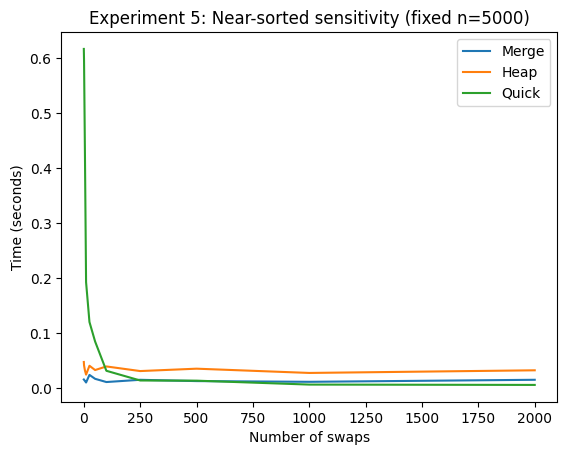

In [41]:
plt.figure()
plt.plot(swaps_values, merge_times, label="Merge")
plt.plot(swaps_values, heap_times,  label="Heap")
plt.plot(swaps_values, quick_times, label="Quick")
plt.xlabel("Number of swaps")
plt.ylabel("Time (seconds)")
plt.title("Experiment 5: Near-sorted sensitivity (fixed n=5000)")
plt.legend()
plt.show()


#Executive Summary
Qhen we have a fixed size array of values such as n = 5000 quick sort is very slow when the list is nearly sorted as there are very slow swaps, but its runtime drops sharply as the number of swaps increase and the input becomes more random. in contrast to that mergesort and heapsort stay reletivly the same regardless of how sorted the input data is. This shows that quick sort implmentationperforms poorly with near sorted data, while merge/heapsort provide a more consistent performance regardless of order. 